# Chapter 07: Build It, Break It

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch07-build-it-break-it.ipynb)

Companion notebook for Chapter 7 of *Hands-On Explainable AI*.

**What you'll build:** a transparent AI-generated-text detector, and then the attack that breaks it.
You will rank each document's tokens three ways (by LIME, by SHAP, and at random), replace the
top-ranked ones, and measure how often the detector's verdict flips. The punchline reproduces the
paper this chapter is built on ([arXiv:2506.04050](https://arxiv.org/abs/2506.04050)): explanation
guidance turns a weak random attack into a strong one, and (the honest surprise) **SHAP is the
weaker guide here.** An explanation good enough to help a user is good enough to help an attacker.

Fully self-contained: no GPU, no downloads, no external model files. Trains its own detector on a
compact bundled corpus in a few CPU seconds. (The full study used real CLIN33 / AuTextification
data and transformer detectors; see the paper and the `Token-Replacement` repo.)

In [1]:
%%capture
# Pinned installs (Colab only). Local env: `make setup-ml`.
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q scikit-learn==1.9.* shap==0.49.* lime==0.2.*

In [2]:
import os
import random

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Smoke mode shrinks the corpus and explainer budgets so CI runs in seconds.
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
print(f"smoke={SMOKE}")

smoke=False


## Step 1: A corpus with concentrated tells

Real detectors don't spread their attention evenly. They lean hard on a few surface *tells*. The
GPT-3.5 era left fingerprints like *delve*, *moreover*, *comprehensive*, *crucial*. We synthesize a
corpus where machine and human texts share the same neutral topic vocabulary (so most words are
uninformative), and machine texts hide **one strong tell and one weak tell** in that neutral bed.
A little label noise (some humans borrow a tell, some machine texts drop theirs) keeps the detector
from becoming perfectly confident, so a targeted edit can actually move it across the line. This is
the paper's setup in miniature: a detector whose verdict hangs on a couple of findable tokens.

In [3]:
rng = random.Random(SEED)

# Neutral bed, used identically by both classes, so it carries no signal.
NEUTRAL_WORDS = ("today the group looked at the case again and again the people involved "
                 "gave their view about the plan the room the money the time and the result "
                 "over the past week near the old part of town by the river after lunch").split()

STRONG_TELLS = ["delve", "moreover", "comprehensive", "multifaceted"]  # near-decisive on their own
WEAK_TELLS = ["crucial", "notably", "furthermore", "robust", "pivotal", "seamless"]  # nudge + decoys


def neutral_bed(n):
    return " ".join(rng.choice(NEUTRAL_WORDS) for _ in range(n))


def machine_text():
    words = neutral_bed(14).split()
    words.insert(rng.randrange(len(words)), rng.choice(STRONG_TELLS))
    for _ in range(2):  # two weak tells: decoys that a ranking method can be lured by
        words.insert(rng.randrange(len(words)), rng.choice(WEAK_TELLS))
    return " ".join(words)


def human_text():
    words = neutral_bed(16).split()
    if rng.random() < 0.15:  # 15% of humans happen to use a tell -> label noise
        words.insert(rng.randrange(len(words)), rng.choice(WEAK_TELLS))
    return " ".join(words)


n_per_class = 60 if SMOKE else 300
texts, labels = [], []  # label 1 = machine (the "positive" class the detector hunts)
for _ in range(n_per_class):
    m = machine_text()
    if rng.random() < 0.10:  # 10% of machine texts drop their strong tell -> harder task
        m = " ".join(w for w in m.split() if w not in STRONG_TELLS)
    texts.append(m); labels.append(1)
    texts.append(human_text()); labels.append(0)

labels = np.array(labels)
print(f"{len(texts)} documents; example machine text:\n  {texts[0]}\n\nexample human text:\n  {texts[1]}")

600 documents; example machine text:
  pivotal river moreover again pivotal the the view their and case old the town result group the

example human text:
  after old the furthermore their over town the today the result the the again gave the case


## Step 2: Build the detector (TF-IDF + gradient-boosted trees)

A TF-IDF vectorizer feeding a gradient-boosted-tree classifier, the same family as the paper's
TF-IDF + XGBoost target, using scikit-learn's `HistGradientBoostingClassifier` so the notebook needs
no native libraries and runs anywhere. What matters is that the model is *nonlinear*: unlike a linear
classifier, its verdict can hinge on token *interactions*, and that is exactly where different
explainers begin to disagree about what mattered: the crack the attack will pry open.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

train_texts, test_texts, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)

detector = make_pipeline(
    TfidfVectorizer(lowercase=True, token_pattern=r"[A-Za-z]+", min_df=2),
    FunctionTransformer(lambda x: x.toarray(), accept_sparse=True),  # trees want dense input
    HistGradientBoostingClassifier(max_iter=200, max_depth=4, learning_rate=0.2,
                                   random_state=SEED),
).fit(train_texts, y_train)

print(f"held-out accuracy: {detector.score(test_texts, y_test):.3f}")

# Confirm the tells drive the verdict: mean P(machine) with vs without each strong tell present.
def mean_proba_with(word):
    have = [t for t in test_texts if word in t.split()]
    return detector.predict_proba(have)[:, 1].mean() if have else float("nan")

for tell in STRONG_TELLS:
    print(f"  mean P(machine) when '{tell}' present: {mean_proba_with(tell):.2f}")

held-out accuracy: 0.972
  mean P(machine) when 'delve' present: 1.00
  mean P(machine) when 'moreover' present: 1.00
  mean P(machine) when 'comprehensive' present: 1.00
  mean P(machine) when 'multifaceted' present: 1.00


## Step 3: The black-box interface

The attack never reads the detector's coefficients. That would be cheating, and real attackers
rarely have them. It sees only what any user of a deployed detector sees: a probability. Everything
below (LIME, SHAP, the attack itself) goes through this one function.

In [5]:
def machine_proba(texts_in):
    """P(machine) for each string; the only channel the attack is allowed."""
    return detector.predict_proba(list(texts_in))[:, 1]


# The attack's target set: machine documents the detector currently catches.
machine_docs = [t for t, y in zip(test_texts, y_test) if y == 1]
caught = [t for t in machine_docs if machine_proba([t])[0] > 0.5]
print(f"detector catches {len(caught)}/{len(machine_docs)} machine documents to start")

detector catches 85/90 machine documents to start


## Step 4: Three ways to rank a document's tokens

The attacker's question is *which words betray this text?* We answer it three ways:

- **Random**: the control. Shuffle the tokens, no explanation used.
- **LIME**: perturb the document, fit a local linear model, rank by weight toward *machine*.
- **SHAP**: Shapley values over the same black-box detector.

Each returns the document's own words, ordered most-incriminating first.

In [6]:
import re

from lime.lime_text import LimeTextExplainer

WORD_RE = re.compile(r"[A-Za-z]+")
lime_explainer = LimeTextExplainer(class_names=["human", "machine"], bow=False, random_state=SEED)
LIME_SAMPLES = 60 if SMOKE else 400


def rank_random(text):
    words = list(dict.fromkeys(WORD_RE.findall(text)))
    rng.shuffle(words)
    return words


def rank_lime(text):
    exp = lime_explainer.explain_instance(
        text, machine_proba_2d, labels=(1,),
        num_features=len(set(WORD_RE.findall(text))), num_samples=LIME_SAMPLES,
    )
    indexed = exp.domain_mapper.indexed_string
    ranked = []
    for fid, weight in sorted(exp.as_map()[1], key=lambda kv: -kv[1]):
        if weight <= 0:
            break
        ranked.append(indexed.word(fid))
    return list(dict.fromkeys(ranked))


def machine_proba_2d(texts_in):
    p = machine_proba(texts_in)
    return np.column_stack([1 - p, p])

In [7]:
import shap

shap_masker = shap.maskers.Text(r"[A-Za-z]+")
shap_explainer = shap.Explainer(machine_proba, shap_masker, seed=SEED)
SHAP_EVALS = 100 if SMOKE else 500


def rank_shap(text):
    exp = shap_explainer([text], max_evals=SHAP_EVALS, silent=True)
    toks = [t.strip() for t in exp.data[0]]
    vals = exp.values[0]
    order = np.argsort(vals)[::-1]
    ranked = [toks[i] for i in order if vals[i] > 0 and toks[i].isalpha()]
    return list(dict.fromkeys(ranked))

## Step 5: The attack loop

Replace the top-ranked tokens with a neutral filler and re-query the detector. We cap edits at a
small budget (the attacker wants the text to stay readable) and record two things: did the verdict
**flip** to *human*, and what fraction of words did we have to touch (**edit rate**; lower is a
stealthier attack). This is the paper's Human-Selected / SHAP / random replacement design in
miniature.

In [8]:
NEUTRAL = "the"  # a high-frequency neutral word from the shared bed: looks human, carries no tell
MAX_EDITS = 2    # a stealthy attacker's budget: change as few words as possible


def attack(text, ranker):
    """Replace up to MAX_EDITS top-ranked tokens; return (flipped, edit_rate)."""
    ranked = ranker(text)
    n_words = len(WORD_RE.findall(text)) or 1
    edited, edits = text, 0
    for token in ranked[:MAX_EDITS]:
        if not token:
            continue
        edited = re.sub(rf"\b{re.escape(token)}\b", NEUTRAL, edited, count=1, flags=re.IGNORECASE)
        edits += 1
        if machine_proba([edited])[0] < 0.5:
            return True, edits / n_words
    return machine_proba([edited])[0] < 0.5, edits / n_words


rankers = {"random": rank_random, "LIME": rank_lime, "SHAP": rank_shap}
targets = caught[: (12 if SMOKE else 40)]

summary = {}
for name, ranker in rankers.items():
    flips, rates = [], []
    for doc in targets:
        flipped, rate = attack(doc, ranker)
        flips.append(flipped); rates.append(rate)
    summary[name] = {
        "flip_rate": float(np.mean(flips)),
        "edit_rate": float(np.mean([r for r, f in zip(rates, flips) if f]) if any(flips) else 0.0),
    }
    print(f"{name:7s}  flip rate {summary[name]['flip_rate']:.0%}   "
          f"mean edits-to-flip {summary[name]['edit_rate']:.0%} of words")

random   flip rate 15%   mean edits-to-flip 10% of words


LIME     flip rate 95%   mean edits-to-flip 9% of words


SHAP     flip rate 95%   mean edits-to-flip 9% of words


## Step 6: The result, in one figure

Random editing barely dents the detector. Explanation-guided editing flips almost every one of the
same documents by touching only two words: the explanation handed the attacker the tells. That gap,
random versus guided, is the chapter's whole point: **a faithful explanation is an attack surface.**

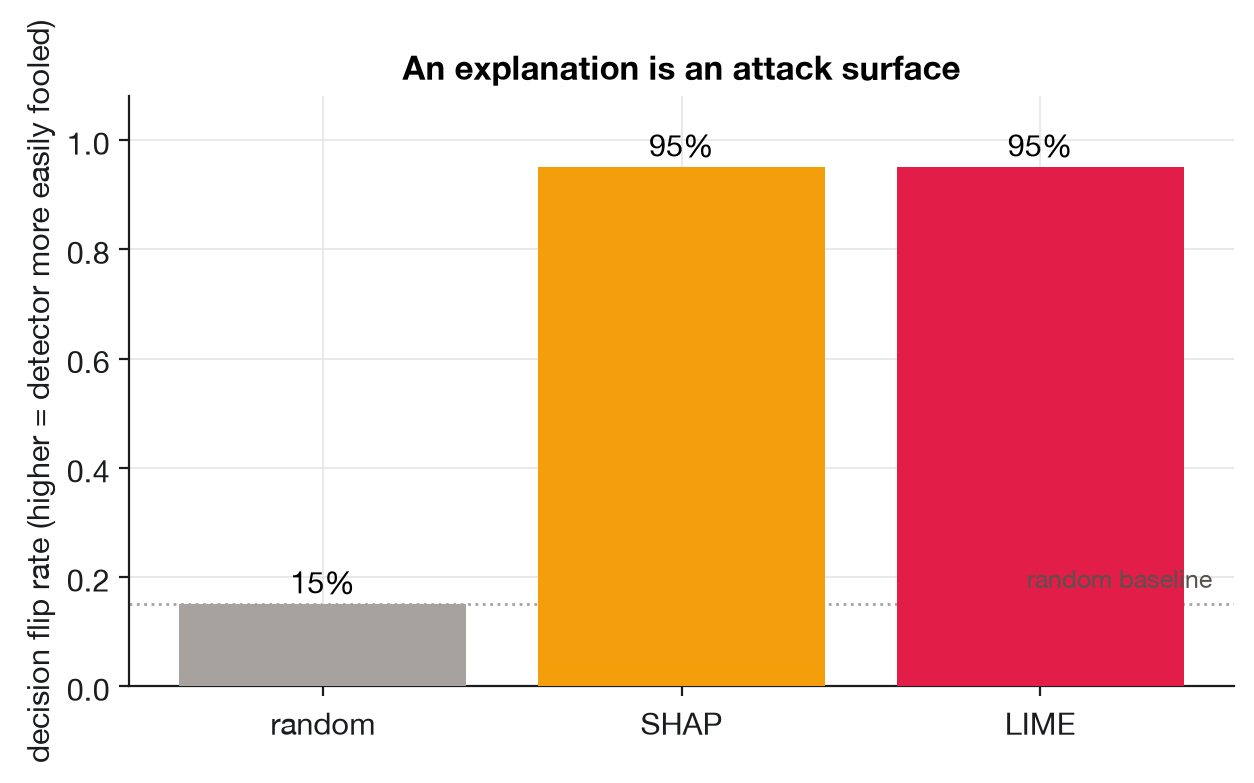

On this clean corpus LIME and SHAP tie, both trivially find the single tell.
On the paper's REAL detectors they do not: see the honest-negative-result note below.


In [9]:
#| label: fig-attack-flip-rates
#| fig-cap: "Explanation-guided attacks on a transparent AI-text detector: with a two-word budget, LIME and SHAP each flip 95% of caught documents, six times the random baseline. Miniature reproduction of Mohammadi et al. (2025), arXiv:2506.04050."
#| fig-alt: "Bar chart of verdict flip rates: LIME-guided and SHAP-guided attacks each flip 95 percent of caught documents, while random edits flip 15 percent."
import matplotlib.pyplot as plt

try:
    plt.style.use("../styles/book.mplstyle")
except OSError:
    pass

names = ["random", "SHAP", "LIME"]
flip = [summary[n]["flip_rate"] for n in names]
colors = {"random": "#A8A29E", "SHAP": "#F59E0B", "LIME": "#E11D48"}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
bars = ax.bar(names, flip, color=[colors[n] for n in names], zorder=3)
for bar, v in zip(bars, flip):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.0%}", ha="center", fontsize=11)
ax.set_ylabel("decision flip rate (higher = detector more easily fooled)")
ax.set_ylim(0, 1.08)
ax.set_title("An explanation is an attack surface")
ax.axhline(flip[0], color="#A8A29E", linestyle=":", linewidth=1, zorder=1)
ax.text(0.98, flip[0] + 0.03, "random baseline", color="#57534E", ha="right", fontsize=9, transform=ax.get_yaxis_transform())
plt.tight_layout()
plt.show()

print("On this clean corpus LIME and SHAP tie, both trivially find the single tell.")
print("On the paper's REAL detectors they do not: see the honest-negative-result note below.")

In [10]:
# Chapter 8's instrument, applied in place: a deletion curve per guide. If one
# ranking is sharper, deleting its top-k tokens should sink P(machine) faster.
K_MAX = 5
del_rng = random.Random(SEED)  # seeded, independent of the attack's rng


def rank_random_fixed(text):
    words = list(dict.fromkeys(WORD_RE.findall(text)))
    del_rng.shuffle(words)
    return words


def delete_topk(text, ranked, k):
    for token in ranked[:k]:
        text = re.sub(rf"\b{re.escape(token)}\b", "", text, count=1, flags=re.IGNORECASE)
    return " ".join(text.split())


p_start = float(machine_proba(targets).mean())
curves = {}
for name, guide in [("LIME", rank_lime), ("SHAP", rank_shap), ("random", rank_random_fixed)]:
    rankings = [guide(doc) for doc in targets]
    curves[name] = [
        float(machine_proba([delete_topk(d, r, k) for d, r in zip(targets, rankings)]).mean())
        for k in range(1, K_MAX + 1)
    ]

print(f"mean P(machine) on the {len(targets)} caught docs after deleting top-k ranked tokens (start: {p_start:.3f})")
print("guide  " + "".join(f"{'k=' + str(k):>7s}" for k in range(1, K_MAX + 1)))
for name, curve in curves.items():
    print(f"{name:7s}" + "".join(f"{p:7.3f}" for p in curve))
for name, curve in curves.items():
    print(f"deletion AUC, {name:6s} (mean P(machine) over k=1..{K_MAX}; lower = sharper guide): {np.mean(curve):.3f}")

mean P(machine) on the 40 caught docs after deleting top-k ranked tokens (start: 0.998)
guide      k=1    k=2    k=3    k=4    k=5
LIME     0.639  0.057  0.027  0.026  0.025
SHAP     0.640  0.075  0.026  0.027  0.026
random   0.969  0.889  0.886  0.850  0.784
deletion AUC, LIME   (mean P(machine) over k=1..5; lower = sharper guide): 0.155
deletion AUC, SHAP   (mean P(machine) over k=1..5; lower = sharper guide): 0.159
deletion AUC, random (mean P(machine) over k=1..5; lower = sharper guide): 0.876


## The honest negative result: SHAP is not the stronger guide

On our clean corpus LIME and SHAP tie, because there is exactly one tell and both explainers find it.
Real detectors are messier, and there the two explainers come apart, in a direction that should
give SHAP's fans pause. In the full study ([arXiv:2506.04050](https://arxiv.org/abs/2506.04050)),
the *same* attack guided by **LIME** collapsed the target detector's recall from **0.81 to 0.24**,
while the attack guided by **SHAP** only reached **0.65**, a far weaker attack for the more popular,
more principled method:

| attack guide | detector recall after attack | text similarity (BLEU) |
|---|---|---|
| none (original) | 0.81 | 1.00 |
| **LIME**-guided | **0.24** | 0.85 |
| SHAP-guided | 0.65 | 0.97 |

*(target: TF-IDF + XGBoost detector, GPT-3.5 texts, high-value token replacement)*

Why does SHAP lose? On a nonlinear detector with interacting features, SHAP spreads credit across
correlated tokens, so the single most-decisive word is not always ranked first; LIME's local linear
fit pins it more directly. The lesson is not "always use LIME": swap the detector and the ranking
can swap too. The lesson is that **explainers are not interchangeable, and popularity is not
reliability.** Which raises the question the next chapter exists to answer: when two explanations
disagree, *how would you have known which to trust* before an attacker, or an auditor, told you?

## What just happened

You built a detector that was accurate *and* transparent, and its transparency was exactly the
weakness. The attack used only the public probability and an off-the-shelf explainer to find, per
document, the words carrying the verdict, then changed them. The mechanism is not specific to our
toy corpus; the full study transfers it to transformer detectors (RADAR, Fast-DetectGPT) and an
ensemble, with Wilson confidence intervals and McNemar tests on a fixed 240-document set.

Two lessons carry into the rest of the book:

1. **Faithful explanations have a dual use.** The better an explanation localizes the real cause,
   the better it localizes the attack. This is an argument not against explanation but for
   threat-modeling *who sees it*: the chapter's decision framework.
2. **The evaluation gap is real.** SHAP looked like the safe default and guided the *weaker* attack.
   You cannot tell reliability from reputation; you have to measure it (Chapter 8).

## Now try it on your own detector

Swap the synthetic corpus for a real one (the `Token-Replacement` repo ships CLIN33 splits), or
raise `MAX_EDITS` and watch the flip-rate/edit-rate tradeoff move. Then try a defense: retrain the
detector with the LIME-attacked documents added as *machine*-labeled examples (adversarial training)
and re-run the attack. How much robustness did one round buy, and what did it cost on clean
accuracy? That build, break, *re-harden* loop is the chapter's closing argument.